In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
#Data Load
nav = pd.read_csv("../Data/Processed/clean_nav.csv")
transactions = pd.read_csv("../Data/Processed/clean_transactions.csv")
performance = pd.read_csv("../Data/Processed/clean_performance.csv")

In [3]:
#Shape Check
print("NAV:", nav.shape)
print("Transactions:", transactions.shape)
print("Performance:", performance.shape)

NAV: (46000, 3)
Transactions: (32778, 13)
Performance: (40, 19)


In [4]:
#Columns check 
print(nav.columns.tolist())
print()
print(transactions.columns.tolist())
print()
print(performance.columns.tolist())

['amfi_code', 'date', 'nav']

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [5]:
#head check
print(nav.head())
print(transactions.head())
print(performance.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30  

In [6]:
#NAV Trend Analysis
nav['date'] = pd.to_datetime(nav['date'])

daily_nav = nav.groupby('date')['nav'].mean().reset_index()

daily_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


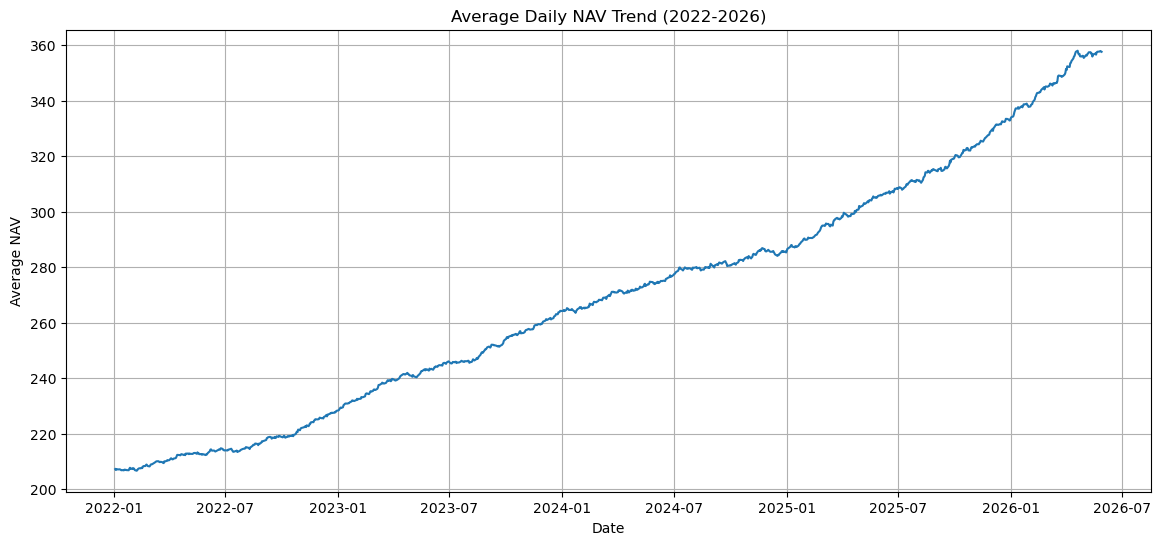

In [7]:
#Chart 1
plt.figure(figsize=(14,6))

plt.plot(daily_nav['date'], daily_nav['nav'])

plt.title('Average Daily NAV Trend (2022-2026)')
plt.xlabel('Date')
plt.ylabel('Average NAV')
plt.grid(True)

plt.show()

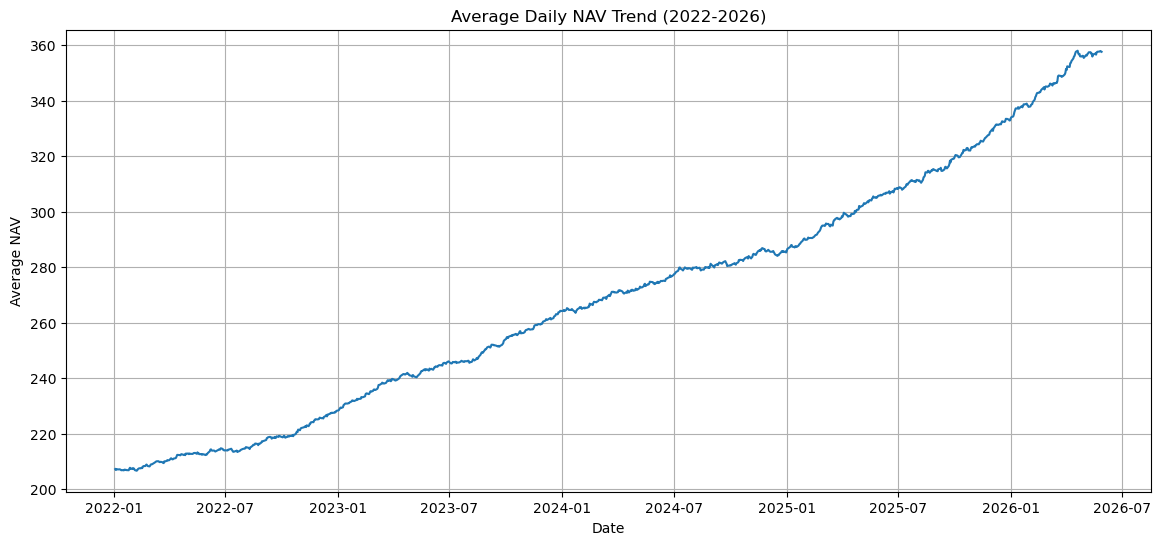

In [8]:
#Save chart 
plt.figure(figsize=(14,6))

plt.plot(daily_nav['date'], daily_nav['nav'])

plt.title('Average Daily NAV Trend (2022-2026)')
plt.xlabel('Date')
plt.ylabel('Average NAV')
plt.grid(True)

plt.savefig('../Reports/nav_trend.png')
plt.show()

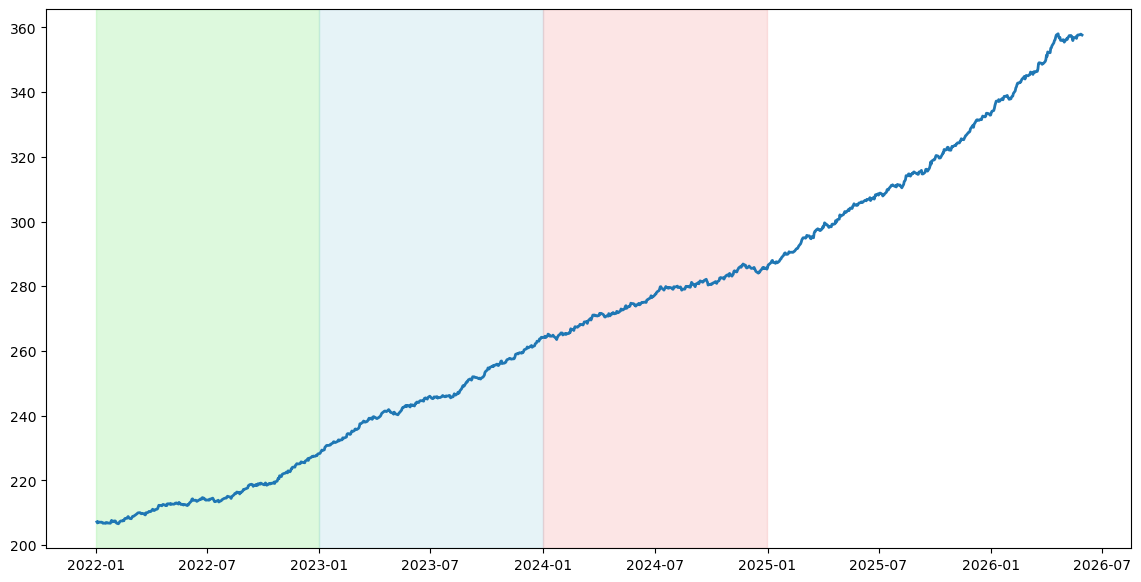

In [12]:
plt.figure(figsize=(14,7))

plt.plot(
    daily_nav['date'],
    daily_nav['nav'],
    linewidth=2,
    label='Average NAV'
)

plt.axvspan(pd.Timestamp('2022-01-01'),
            pd.Timestamp('2022-12-31'),
            color='lightgreen',
            alpha=0.3,
            label='Post-COVID Recovery')

plt.axvspan(pd.Timestamp('2023-01-01'),
            pd.Timestamp('2023-12-31'),
            color='lightblue',
            alpha=0.3,
            label='2023 Rally')

plt.axvspan(pd.Timestamp('2024-01-01'),
            pd.Timestamp('2024-12-31'),
            color='lightcoral',
            alpha=0.2,
            label='2024 Correction')

plt.savefig('../Reports/nav_trend_highlighted.png')
plt.show()

## Chart 1: Average Daily NAV Trend (2022–2026)

### Objective
Analyze the overall movement of average mutual fund NAV across all schemes from 2022 to 2026.

### Observations

- Average NAV increased consistently throughout the analysis period.
- NAV rose from approximately 207 in early 2022 to around 358 by mid-2026.
- The trend indicates strong long-term growth in mutual fund valuations.
- Minor fluctuations were observed but the overall direction remained upward.

### Conclusion

The mutual fund industry demonstrated sustained growth during the study period, reflecting increasing asset values and positive market performance.


## Chart 2: NAV Trend with Market Phase Highlights

### Objective
Highlight major market phases including post-COVID recovery, 2023 rally, and 2024 correction.

### Observations

- **Post-COVID Recovery (2022):**
  - NAV showed gradual recovery and stable growth after pandemic-related volatility.
  - Investor confidence improved steadily.

- **2023 Rally:**
  - Strong acceleration in NAV growth was observed.
  - Market sentiment remained positive, leading to higher fund valuations.

- **2024 Correction:**
  - Growth slowed and temporary consolidation phases appeared.
  - Despite corrections, NAV maintained an upward trajectory.

### Conclusion

Although temporary corrections occurred during 2024, the overall market remained resilient. Recovery in 2022 and strong growth during 2023 contributed significantly to long-term NAV appreciation.

# Task 2

In [21]:
#AUM Growth by Fund House
aum = pd.read_csv('../Data/Raw/03_aum_by_fund_house.csv')
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [19]:
aum = pd.read_csv('../Data/Raw/03_aum_by_fund_house.csv')

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [22]:
aum['date'] = pd.to_datetime(aum['date'])

aum['year'] = aum['date'].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [23]:
aum['year'].unique()

array([2022, 2023, 2024, 2025], dtype=int32)

In [24]:
aum_yearly = aum.groupby(
    ['year', 'fund_house']
)['aum_lakh_crore'].mean().reset_index()

aum_yearly.head()

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.815
1,2022,Axis Mutual Fund,2.450
2,2022,DSP Mutual Fund,1.110
3,2022,HDFC Mutual Fund,4.400
4,2022,ICICI Prudential MF,4.765


In [25]:
pivot_aum = aum_yearly.pivot(
    index='fund_house',
    columns='year',
    values='aum_lakh_crore'
)

pivot_aum.head()

year,2022,2023,2024,2025
fund_house,,,,
Aditya Birla Sun Life MF,2.815,2.915,3.620000,4.225
Axis Mutual Fund,2.450,2.505,2.900000,3.300
DSP Mutual Fund,1.110,1.235,1.716667,2.125
HDFC Mutual Fund,4.400,4.925,7.140000,8.625
ICICI Prudential MF,4.765,5.450,7.653333,9.770


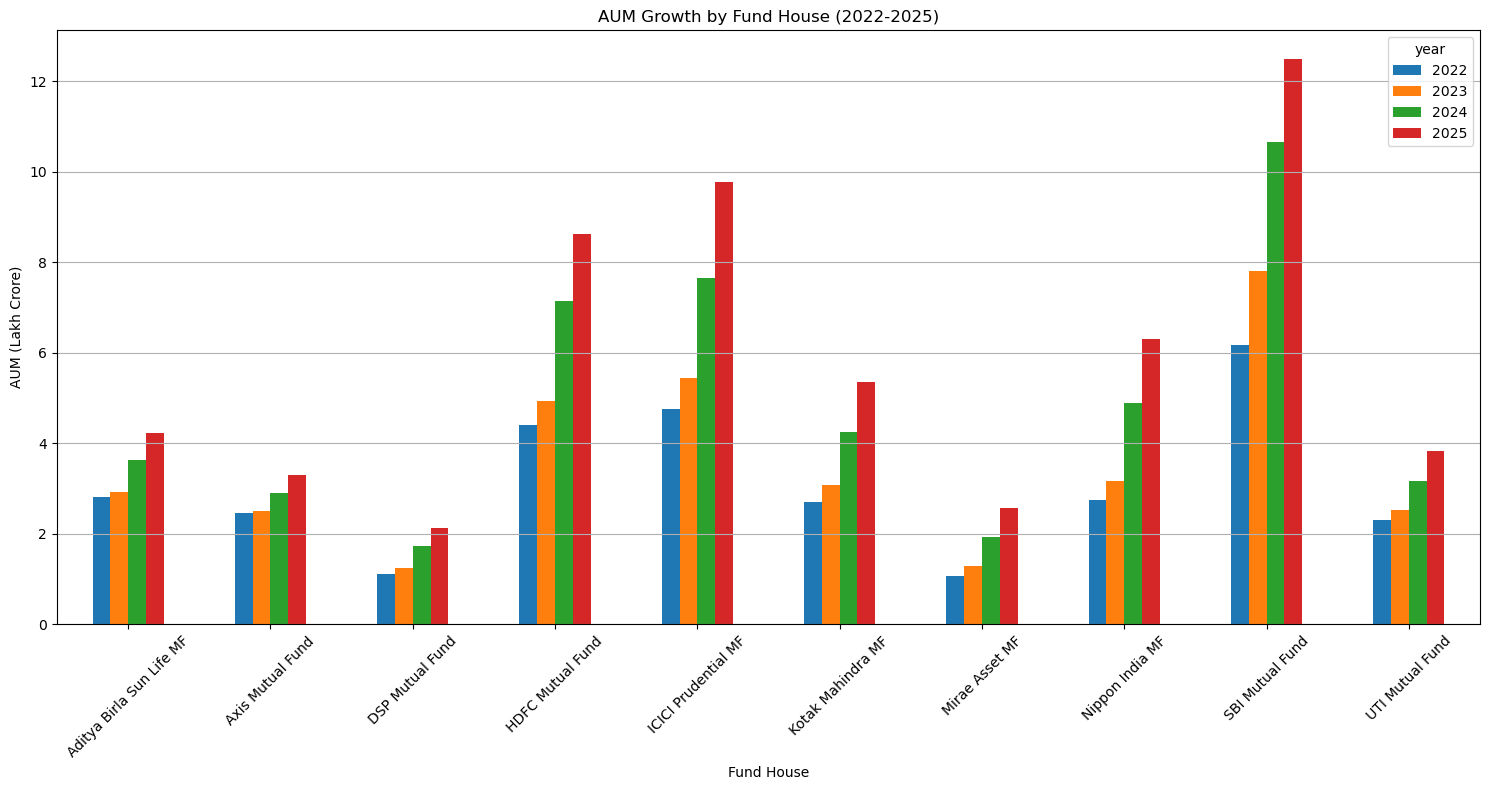

In [29]:
pivot_aum.plot(
    kind='bar',
    figsize=(15,8)
)

plt.title('AUM Growth by Fund House (2022-2025)')
plt.xlabel('Fund House')
plt.ylabel('AUM (Lakh Crore)')
plt.xticks(rotation=45)

plt.grid(axis='y')

plt.tight_layout()

plt.savefig('../Reports/aum_growth_amc.png')

plt.show()

In [28]:
sbi_max = aum.groupby('fund_house')['aum_lakh_crore'].max()['SBI Mutual Fund']

print(f"SBI Mutual Fund reached a peak AUM of {sbi_max:.2f} lakh crore.")

SBI Mutual Fund reached a peak AUM of 12.50 lakh crore.


# Chart 3: AUM Growth by AMC (2022–2025)

## Objective
Analyse Assets Under Management (AUM) growth across major Asset Management Companies (AMCs) between 2022 and 2025.

## Key Findings

- AUM increased consistently across all major AMCs from 2022 to 2025.
- SBI Mutual Fund remained the industry leader throughout the analysis period.
- SBI Mutual Fund achieved the highest AUM of approximately 12.5 lakh crore in 2025.
- ICICI Prudential MF and HDFC Mutual Fund were the next largest AMCs by assets under management.
- The overall growth trend reflects increasing investor participation and confidence in mutual funds.

## Conclusion

The mutual fund industry witnessed strong asset growth between 2022 and 2025. SBI Mutual Fund dominated the market with the highest AUM of approximately 12.5 lakh crore, demonstrating strong investor trust and market leadership. The steady increase in AUM across most AMCs indicates a healthy and expanding mutual fund ecosystem in India.

# Task 3

In [30]:
sip = pd.read_csv('../Data/Raw/04_monthly_sip_inflows.csv')

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


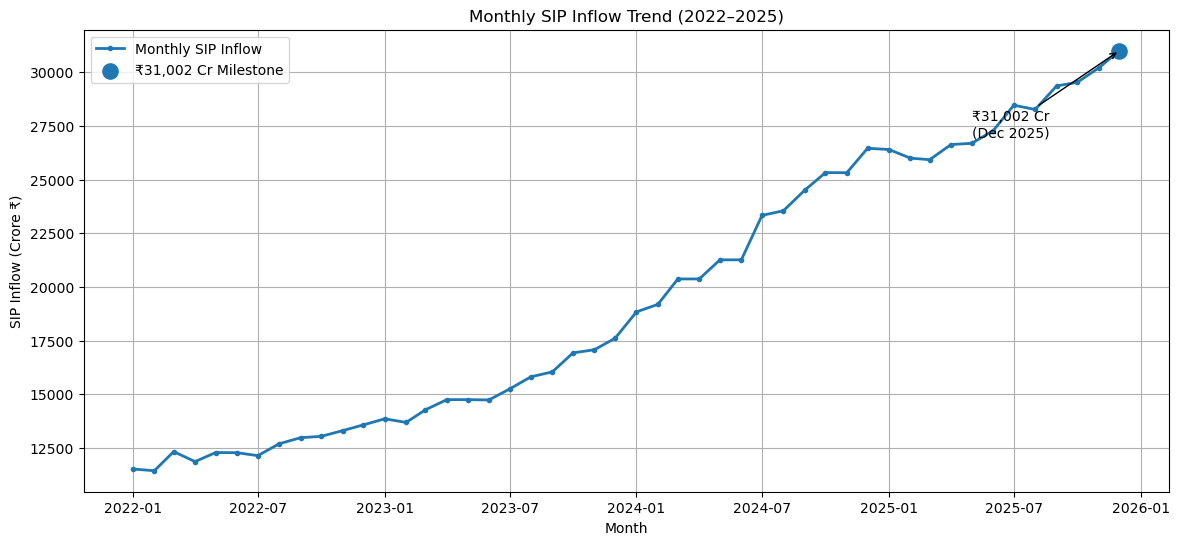

In [33]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(14,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    linewidth=2,
    marker='o',
    markersize=3,
    label='Monthly SIP Inflow'
)

plt.scatter(
    pd.Timestamp('2025-12-01'),
    31002,
    s=120,
    label='₹31,002 Cr Milestone'
)

plt.annotate(
    '₹31,002 Cr\n(Dec 2025)',
    xy=(pd.Timestamp('2025-12-01'), 31002),
    xytext=(pd.Timestamp('2025-05-01'), 27000),
    arrowprops=dict(arrowstyle='->')
)

plt.title('Monthly SIP Inflow Trend (2022–2025)')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore ₹)')
plt.grid(True)
plt.legend()

plt.savefig('../Reports/sip_inflow_trend.png')
plt.show()

# Chart 4: SIP Inflow Trend (2022–2025)

## Objective

Analyse monthly SIP inflows from January 2022 to December 2025 and identify major growth milestones.

## Key Findings

- SIP inflows increased steadily throughout the analysis period.
- Monthly SIP contributions grew from approximately ₹11,517 crore in January 2022 to ₹31,002 crore in December 2025.
- Investor participation through systematic investment plans expanded significantly over time.
- December 2025 recorded the highest monthly SIP inflow of ₹31,002 crore.
- The consistent upward trend reflects growing retail investor confidence in mutual funds.

## Conclusion

SIP inflows demonstrated strong and sustained growth between 2022 and 2025. The milestone of ₹31,002 crore in December 2025 highlights the increasing popularity of disciplined investing through SIPs and the continued expansion of India's mutual fund industry.

# Task 4

In [34]:
category = pd.read_csv('../Data/Raw/05_category_inflows.csv')

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [36]:
category['month'] = pd.to_datetime(category['month'])

In [37]:
heatmap_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


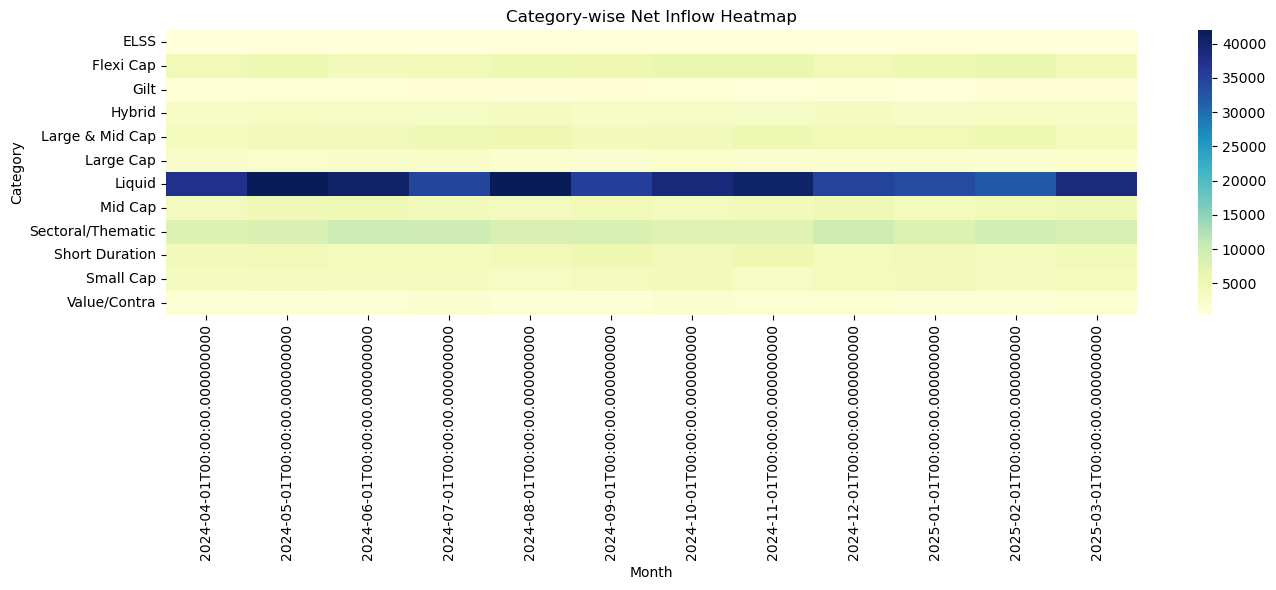

In [38]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False
)

plt.title('Category-wise Net Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Category')

plt.tight_layout()

plt.savefig('../Reports/category_heatmap.png')

plt.show()

# Chart 4: Category-wise Net Inflow Heatmap

## Objective

Analyse net inflows across mutual fund categories and identify categories receiving the highest investor inflows.

## Key Findings

- Liquid Funds received the highest net inflows across most months.
- Sectoral/Thematic and Large & Mid Cap funds also attracted significant investments.
- Small Cap, Flexi Cap and Mid Cap categories showed steady inflow patterns.
- Investor preferences varied across categories, indicating diversification of investment choices.
- Heatmap intensity highlights periods of stronger inflows in specific categories.

## Conclusion

The heatmap reveals that Liquid Funds consistently attracted the highest inflows, reflecting investor preference for liquidity and short-term parking of funds. Other equity-oriented categories also witnessed healthy participation, indicating broad-based growth in mutual fund investments.

# Task 5

In [39]:
investor = pd.read_csv('../Data/Raw/08_investor_transactions.csv')

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


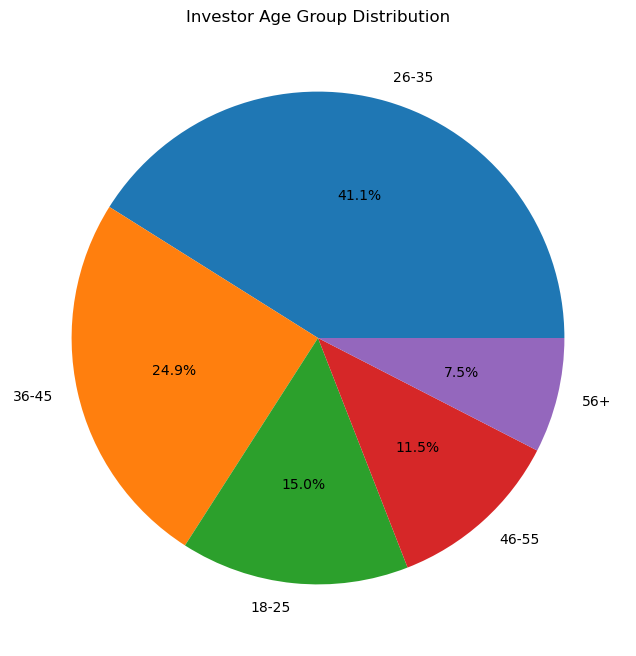

In [41]:
#Age Group Distribution Pie Chart
age_dist = investor['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct='%1.1f%%'
)

plt.title('Investor Age Group Distribution')

plt.savefig('../Reports/age_group_distribution.png')

plt.show()

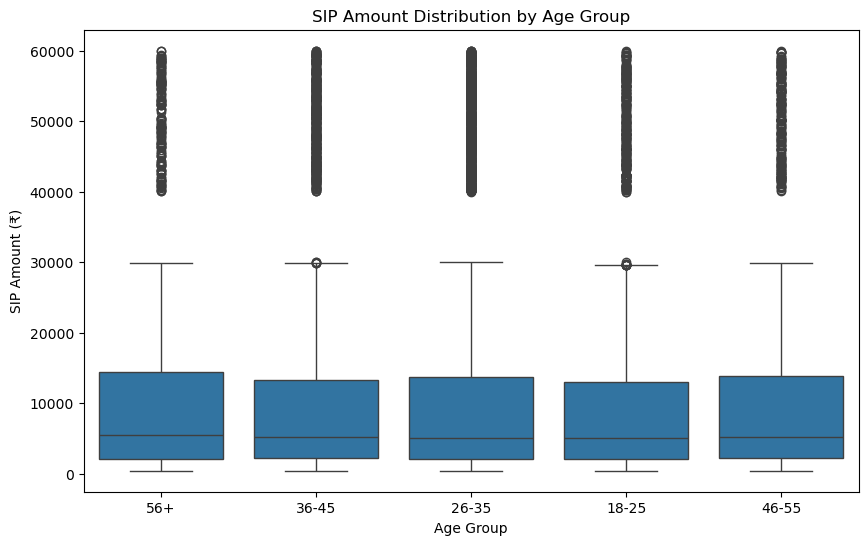

In [42]:
#SIP Amount Box Plot by Age Group
sip_only = investor[investor['transaction_type'] == 'SIP']

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_only,
    x='age_group',
    y='amount_inr'
)

plt.title('SIP Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (₹)')

plt.savefig('../Reports/sip_amount_boxplot_agegroup.png')

plt.show()

# Chart 5A: Investor Age Group Distribution

## Objective

Analyse the distribution of investors across different age groups.

## Key Findings

- Investors are distributed across multiple age groups.
- Working-age investors contribute a significant share of total investors.
- Younger and middle-aged investors form the core mutual fund investor base.
- Senior investors also participate actively in mutual fund investments.

## Conclusion

The investor base is diversified across age groups, indicating broad adoption of mutual funds among different generations of investors.

# Chart 5B: SIP Amount Distribution by Age Group

## Objective

Analyse SIP investment behaviour across different age groups.

## Key Findings

- SIP contribution levels vary across age groups.
- Some age groups exhibit higher median SIP investments.
- Outliers indicate the presence of high-value investors.
- Investment behaviour differs based on age and earning capacity.

## Conclusion

The box plot highlights variations in SIP investment patterns across age groups. Higher-income and experienced investor groups generally contribute larger SIP amounts, while younger investors participate with comparatively smaller investments.

# Task 6

In [46]:
#Chart 6A: SIP Amount by State (Horizontal Bar Chart)
state_sip = investor.groupby('state')['amount_inr'].sum().sort_values()
state_sip

state
Maharashtra       269513480
Karnataka         273753570
Haryana           279634354
Uttar Pradesh     285368873
Delhi             289633404
Telangana         290219284
West Bengal       297182514
Gujarat           298358940
Rajasthan         298645822
Madhya Pradesh    308312493
Tamil Nadu        315177237
Punjab            315780459
Name: amount_inr, dtype: int64

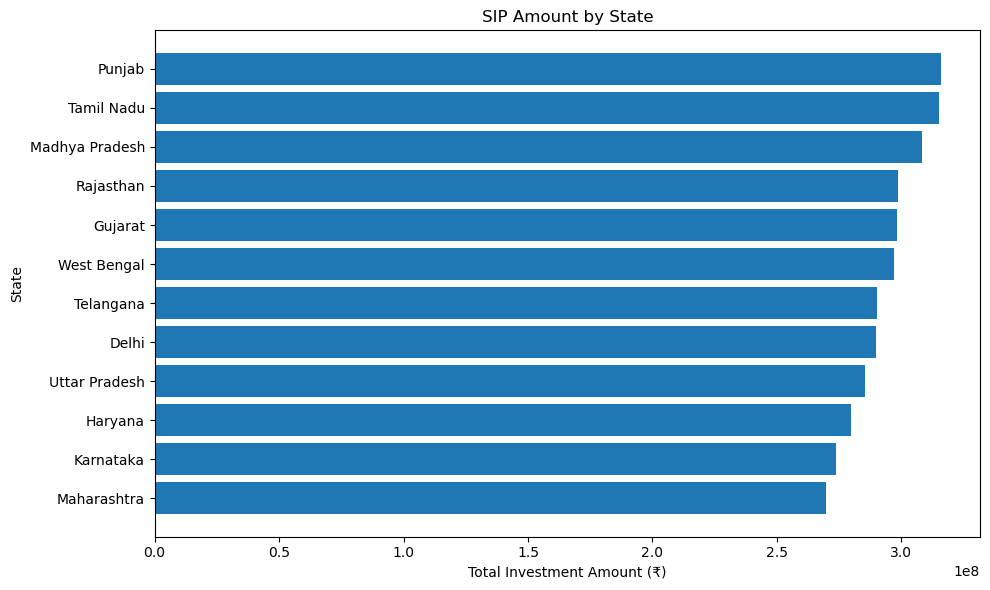

In [47]:
plt.figure(figsize=(10,6))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title('SIP Amount by State')
plt.xlabel('Total Investment Amount (₹)')
plt.ylabel('State')

plt.tight_layout()

plt.savefig('../Reports/sip_by_state.png')

plt.show()

In [48]:
#Chart 6B: T30 vs B30 Pie Chart
tier_data = investor.groupby('city_tier')['amount_inr'].sum()

tier_data

city_tier
B30    1202325640
T30    2319254790
Name: amount_inr, dtype: int64

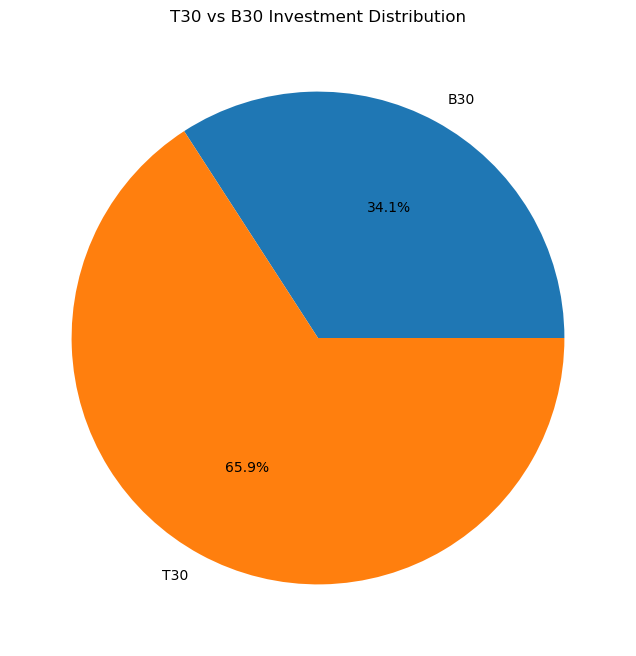

In [49]:
plt.figure(figsize=(8,8))

plt.pie(
    tier_data,
    labels=tier_data.index,
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Investment Distribution')

plt.savefig('../Reports/t30_b30_distribution.png')

plt.show()

# Chart 6A: SIP Amount by State

## Objective

Analyse the geographic distribution of mutual fund investments across different states.

## Key Findings

- Investment activity varies significantly across states.
- Some states contribute a larger share of total SIP investments.
- Regional differences indicate varying levels of financial awareness and participation.
- Major urbanized states show stronger mutual fund adoption.

## Conclusion

The state-wise distribution highlights the geographical spread of mutual fund investments and identifies regions with stronger investor participation.

# Chart 6B: T30 vs B30 Investment Distribution

## Objective

Compare mutual fund investments between Top 30 cities (T30) and Beyond 30 cities (B30).

## Key Findings

- T30 cities contribute a significant portion of total investments.
- B30 cities also represent an important and growing investor base.
- Mutual fund penetration is expanding beyond major metropolitan areas.
- Investor participation is becoming increasingly diversified geographically.

## Conclusion

The comparison between T30 and B30 regions indicates that while major cities continue to dominate investments, participation from smaller cities is steadily increasing, supporting broader financial inclusion.

# Task 7

In [50]:
folio = pd.read_csv('../Data/Raw/06_industry_folio_count.csv')

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [52]:
import plotly.express as px

folio['month'] = pd.to_datetime(folio['month'])

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    markers=True,
    title='Folio Count Growth (2022-2025)'
)

fig.add_annotation(
    x=folio['month'].iloc[0],
    y=folio['total_folios_crore'].iloc[0],
    text='13.26 Cr',
    showarrow=True
)

fig.add_annotation(
    x=folio['month'].iloc[-1],
    y=folio['total_folios_crore'].iloc[-1],
    text='26.12 Cr',
    showarrow=True
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Total Folios (Crore)'
)

fig.show()

In [56]:
fig.write_image('../Reports/folio_count_growth.png')

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
